##### This notebook runs the model in the limit case where we do not have Boltz inputs, and the non contrastive loss takes place simply on the sequences
##### Overview:
- The inputs are ESMC embeddings
- 3 encoders from PEFT of ESMC
- Two projection heads: one for ESM embeddings and one for Boltz embeddings, but the Boltz is unused as it becomes the Identity
- Non contrastive learning

In [1]:
# list of changes mnade that I need to replicate across the otehr model notebooks:

# 1. changed loading the embeddings one by one to shard dataset
# 2. Changed the EmbeddingTripletDataset to load the embeddings from shards

In [52]:
# imports
import time
import esm
import pandas as pd
import torch
from torch import Tensor
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.nn.utils.rnn import pad_sequence
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import copy
from datetime import datetime

import sys
import os
import time
import math
import random
import pickle
import subprocess
import gc
from pathlib import Path
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display, update_display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ESM imports
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinTensor
from esm.models.esmc import _BatchedESMProteinTensor

# Tokenizer imports
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers import normalizers
from tokenizers.normalizers import NFD, Lowercase, StripAccents
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordPieceTrainer
from tokenizers import decoders

# PEFT imports
from peft import get_peft_model, LoraConfig, TaskType
from peft.tuners.lora import LoraConfig, LoraModel


# validation function imports
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

# Set environment variable
os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [53]:

model_type = 'baseline'
model_name = 'baseline_without_boltz'
# hyperparameters 

In [110]:
# Get current working directory and create models folder
import os
from pathlib import Path

# Get the current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Get the project root (go up one level from scripts/train)
project_root = Path(current_dir).parent.parent
print(f"Project root: {project_root}")

# Create models directory in project root
models_dir = project_root / "models"
if not models_dir.exists():
    print(f"Models directory does not exist, creating it at: {models_dir}")
    models_dir.mkdir(exist_ok=True)
print(f"Models directory at: {models_dir}")

# Also create a checkpoints subdirectory for saving model checkpoints
checkpoints_dir = models_dir / "checkpoints"
if not checkpoints_dir.exists():
    print(f"Checkpoints directory does not exist, creating it at: {checkpoints_dir}")
    checkpoints_dir.mkdir(exist_ok=True)
print(f"Checkpoints directory at: {checkpoints_dir}")


embeddings_dir = models_dir / "embeddings"
if not embeddings_dir.exists():
    print(f"Embeddings directory does not exist, creating it at: {embeddings_dir}")
    embeddings_dir.mkdir(exist_ok=True)
print(f"Embeddings directory at: {embeddings_dir}")


figure_dir = models_dir / "figures"
if not figure_dir.exists():
    print(f"Figures directory does not exist, creating it at: {figure_dir}")
    figure_dir.mkdir(exist_ok=True)
print(f"Figures directory at: {figure_dir}")


Current working directory: /home/natasha/multimodal_model/scripts/train
Project root: /home/natasha/multimodal_model
Models directory at: /home/natasha/multimodal_model/models
Checkpoints directory at: /home/natasha/multimodal_model/models/checkpoints
Embeddings directory at: /home/natasha/multimodal_model/models/embeddings
Figures directory at: /home/natasha/multimodal_model/models/figures


##### Get ESM Embeddings

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_CSV = "/home/natasha/multimodal_model/data/train/train_df_clean.csv"
VAL_CSV   = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv"
TEST_CSV  = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv"

EMBED_ROOT = Path(embeddings_dir / "no_boltz")
EMBED_ROOT.mkdir(parents=True, exist_ok=True)

In [55]:
def load_split_sequences(
    csv_path,
    tcr_col="TCR_full",
    peptide_col="Peptide",
    hla_col="HLA_sequence",
    binding_col="binding_flag",
    pair_id_col="pair_id",
):
    df = pd.read_csv(csv_path).reset_index(drop=True)

    required = [tcr_col, peptide_col, hla_col, binding_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {csv_path}: {missing}")

    tcrs_data = df[tcr_col].astype(str).tolist()
    peptides_data = df[peptide_col].astype(str).tolist()
    hlas_data = df[hla_col].astype(str).tolist()
    binding_flags = df[binding_col].astype(int).tolist()

    if pair_id_col in df.columns:
        pair_ids = df[pair_id_col].tolist()
    else:
        pair_ids = list(range(len(df)))

    return {
        "df": df,
        "tcrs_data": tcrs_data,
        "peptides_data": peptides_data,
        "hlas_data": hlas_data,
        "binding_flags": binding_flags,
        "pair_ids": pair_ids,
    }

In [56]:
train_split = load_split_sequences(TRAIN_CSV)

##### Mask Data and Collate for MLM for Encoders

In [15]:
# do for entire dataset
# do we also want to output attention_mask from the tokenizer?
model = ESMC.from_pretrained("esmc_300m").eval()

tok = model.tokenizer
CLS_ID = tok.cls_token_id
EOS_ID = tok.eos_token_id
PAD_ID = tok.pad_token_id
MASK_ID = tok.mask_token_id

AA_IDS =  [5,10,17,13,23,16,9,6,21,12,4,15,20,18,14,8,11,22,19,7]


class EncodedSeqDataset(Dataset):
    def __init__(self, sequences, enc):     # ← now takes two arguments
        self.sequences = sequences          # list[str]
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "sequence": self.sequences[idx],  # raw sequence string
            "input_ids": torch.as_tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.as_tensor(self.attention_mask[idx], dtype=torch.long),
        }


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [16]:
class MLMProteinCollator:
    def __init__(self, *, cls_id, eos_id, pad_id, mask_id, amino_acids,
                 p=0.15, min_per_seq=2, max_per_seq=45, aa_frac=0.20):
        self.CLS = cls_id
        self.EOS = eos_id
        self.PAD = pad_id
        self.MASK = mask_id
        self.aa = torch.as_tensor(amino_acids, dtype=torch.long)
        self.p = p
        self.min_per_seq = min_per_seq
        self.max_per_seq = max_per_seq
        self.aa_frac = aa_frac
        

    @torch.no_grad()
    def mask_batch(self, input_ids, attention_mask):
        device = input_ids.device
        aa = self.aa.to(device)

        B, L = input_ids.shape
        valid_mask = attention_mask.bool() \
                   & (input_ids != self.PAD) \
                   & (input_ids != self.CLS) \
                   & (input_ids != self.EOS)

        masked_input_ids = input_ids.clone()
        labels = torch.full_like(input_ids, -100)

        for i in range(B):
            vmask = valid_mask[i]
            if not vmask.any():
                continue

            valid_idx = vmask.nonzero(as_tuple=False).squeeze(1)  # (L_valid,)
            L_valid = valid_idx.numel()

            # how many to mask: floor(p*L_valid), clamped to [2, 45] but never > L_valid
            n = torch.floor(self.p * torch.tensor(L_valid, device=device, dtype=torch.float32)).to(torch.int64)
            n = torch.clamp(n, min=self.min_per_seq, max=min(self.max_per_seq, L_valid))
            if n.item() == 0:
                continue

            # choose n distinct valid positions
            chosen = valid_idx[torch.randperm(L_valid, device=device)[:n]]

            # split into AA vs MASK; ensure >=1 AA if n>=2
            n_amino = torch.floor(self.aa_frac * n).to(torch.int64)
            if n.item() >= 2:
                n_amino = torch.clamp(n_amino, min=1)
            n_mask = n - n_amino

            order = torch.randperm(n.item(), device=device)
            mask_pos  = chosen[order[:n_mask]]
            amino_pos = chosen[order[n_mask:]]

            # labels only at supervised positions
            labels[i, chosen] = input_ids[i, chosen]

            # apply edits
            if n_mask.item() > 0:
                masked_input_ids[i, mask_pos] = self.MASK
            if n_amino.item() > 0:
                r_idx = torch.randint(high=aa.numel(), size=(n_amino.item(),), device=device)
                masked_input_ids[i, amino_pos] = aa[r_idx]

        return masked_input_ids, labels


    def __call__(self, features):
        input_ids = torch.stack([f["input_ids"] for f in features], dim=0)
        attention_mask = torch.stack([f["attention_mask"] for f in features], dim=0)
        sequences = [f["sequence"] for f in features]
        proteins = [ESMProtein(sequence=f["sequence"]) for f in features]
        batched_clean = _BatchedESMProteinTensor(sequence=input_ids)


        masked_input_ids, labels = self.mask_batch(input_ids, attention_mask)

        # build masked sequences as strings (keep <mask>, drop CLS/EOS/PAD)
        masked_sequences = []
        for row in masked_input_ids.tolist():
            #toks = collator.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            toks = self.tokenizer.convert_ids_to_tokens(row, skip_special_tokens=False)
            aa = []
            for t in toks:
                if t in (self.tokenizer.cls_token, self.tokenizer.eos_token, self.tokenizer.pad_token):
                #if t in (collator.tokenizer.cls_token, collator.tokenizer.eos_token, collator.tokenizer.pad_token):
                    continue
                aa.append(t)  # AA tokens are single letters; keep "<mask>" as is
            masked_sequences.append("".join(aa))

        proteins_masked = [ESMProtein(sequence=s) for s in masked_sequences]
        batched_masked = _BatchedESMProteinTensor(sequence=masked_input_ids)


        return {
            "masked_input_ids": masked_input_ids,
            "labels": labels,
            "attention_mask": attention_mask,
            "clean_input_ids": input_ids.clone(),
            "clean_sequences": sequences,                 # clean strings
            "masked_sequences": masked_sequences,   # masked strings  ← NEW
            "clean_sequences_ESMprotein": proteins,
            "masked_sequences_ESMprotein": proteins_masked,
            "masked_input_ids_ESMprotein_batched": batched_masked,
            "clean_input_ids_ESMprotein_batched": batched_clean,
        }

In [64]:
class CleanSeqDataset(Dataset):
    def __init__(self, sequences, tokenizer):
        self.sequences = sequences
        enc = tokenizer(sequences, return_tensors="pt", padding=True)
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
        }


def clean_collate(features):
    return {
        "input_ids": torch.stack([f["input_ids"] for f in features], dim=0),
        "attention_mask": torch.stack([f["attention_mask"] for f in features], dim=0),
    }

In [65]:
def build_modality_loaders(
    model,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    clean_tcrs_tokenized = model.tokenizer(tcrs_data, return_tensors="pt", padding=True)
    clean_peptides_tokenized = model.tokenizer(peptides_data, return_tensors="pt", padding=True)
    clean_hlas_tokenized = model.tokenizer(hlas_data, return_tensors="pt", padding=True)

    tcr_ds = EncodedSeqDataset(tcrs_data, clean_tcrs_tokenized)
    pep_ds = EncodedSeqDataset(peptides_data, clean_peptides_tokenized)
    hla_ds = EncodedSeqDataset(hlas_data, clean_hlas_tokenized)

    collator = MLMProteinCollator(
        cls_id=CLS_ID,
        eos_id=EOS_ID,
        pad_id=PAD_ID,
        mask_id=MASK_ID,
        amino_acids=AA_IDS,
        p=0.15,
        min_per_seq=2,
        max_per_seq=45,
        aa_frac=0.20,
    )
    collator.tokenizer = model.tokenizer

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=collator)

    return tcr_loader, pep_loader, hla_loader

In [66]:
def build_clean_loaders(
    tokenizer,
    tcrs_data,
    peptides_data,
    hlas_data,
    batch_size=8,
    num_workers=4,
    shuffle=False,
):
    tcr_ds = CleanSeqDataset(tcrs_data, tokenizer)
    pep_ds = CleanSeqDataset(peptides_data, tokenizer)
    hla_ds = CleanSeqDataset(hlas_data, tokenizer)

    tcr_loader = DataLoader(tcr_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    pep_loader = DataLoader(pep_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)
    hla_loader = DataLoader(hla_ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, num_workers=num_workers, collate_fn=clean_collate)

    return tcr_loader, pep_loader, hla_loader

In [ ]:
#model = ESMC.from_pretrained("esmc_300m").eval()
#base = ESMC.from_pretrained("esmc_300m")

train_tcr_loader, train_pep_loader, train_hla_loader = build_modality_loaders(
    model=model,
    tcrs_data=train_split["tcrs_data"],
    peptides_data=train_split["peptides_data"],
    hlas_data=train_split["hlas_data"],
    batch_size=8,
    num_workers=4,
    shuffle=True,
)

# when we reload for train, test and val we will not shuffle

In [69]:
def optimizer_to_cpu(optim):
    for st in optim.state.values():
        for k, v in list(st.items()):
            if torch.is_tensor(v):
                st[k] = v.detach().to("cpu")

In [ ]:
num_epochs = 3
base_tcr = ESMC.from_pretrained("esmc_300m")

use_amp = torch.cuda.is_available()

lora_cfg = LoraConfig(
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

model_tcr = LoraModel(base_tcr, lora_cfg, adapter_name="tcr")

for p in model_tcr.parameters():
    p.requires_grad = False
for name, p in model_tcr.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_tcr.to(device)
model_tcr.train()

optim_tcr = torch.optim.AdamW(
    (p for p in model_tcr.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01,
)

scaler = GradScaler(enabled=False)

epoch_losses = []

for epoch in range(num_epochs):
    model_tcr.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_tcr_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_tcr.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_tcr(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_tcr.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - TCR MLM loss: {avg_epoch_loss:.4f}")


optimizer_to_cpu(optim_tcr)

checkpoint_filename = "tcr_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "tcr_model_state_dict": model_tcr.state_dict(),
    "optimizer_state_dict": optim_tcr.state_dict(),
    "epoch_losses": epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_tcr.to("cpu")
del optim_tcr, model_tcr, checkpoint_dict
torch.cuda.empty_cache()


# took 6 minutes for 1 epochs on 31K pairs
# took 14 minutes for 3 epochs on 31K pairs

/tmp/ipykernel_250200/1484538120.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - TCR MLM loss: 0.3571
Epoch 2/3 - TCR MLM loss: 0.1436
Epoch 3/3 - TCR MLM loss: 0.1239
Checkpoint saved to tcr_encoder_checkpoint.pth


In [ ]:
# peptide encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_pep = ESMC.from_pretrained("esmc_300m")
model_pep = LoraModel(base_pep, lora_cfg, adapter_name="pep")

# freeze everything; unfreeze only LoRA params
for p in model_pep.parameters():
    p.requires_grad = False
for name, p in model_pep.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_pep.to(device)
model_pep.train()

optim_pep = torch.optim.AdamW(
    (p for p in model_pep.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

pep_epoch_losses = []

for epoch in range(num_epochs):
    model_pep.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_pep_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_pep.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_pep(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_pep.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    pep_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - peptide MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_pep)

checkpoint_filename = "peptide_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "peptide_model_state_dict": model_pep.state_dict(),
    "optimizer_state_dict": optim_pep.state_dict(),
    "epoch_losses": pep_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_pep.to("cpu")
del optim_pep, model_pep, checkpoint_dict
torch.cuda.empty_cache()

# took 6 mins for train dataset (31K pairs)

/tmp/ipykernel_250200/3964876094.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - peptide MLM loss: 2.3571
Epoch 2/3 - peptide MLM loss: 2.5767
Epoch 3/3 - peptide MLM loss: 2.5740
Checkpoint saved to peptide_encoder_checkpoint.pth


In [ ]:
# HLA encoder

num_epochs = 3
use_amp = torch.cuda.is_available()

base_hla = ESMC.from_pretrained("esmc_300m")
model_hla = LoraModel(base_hla, lora_cfg, adapter_name="hla")

# freeze everything; unfreeze only LoRA params
for p in model_hla.parameters():
    p.requires_grad = False
for name, p in model_hla.named_parameters():
    if "lora_A" in name or "lora_B" in name:
        p.requires_grad = True

model_hla.to(device)
model_hla.train()

optim_hla = torch.optim.AdamW(
    (p for p in model_hla.parameters() if p.requires_grad),
    lr=1e-4,
    weight_decay=0.01
)

scaler = GradScaler(enabled=False)

hla_epoch_losses = []

for epoch in range(num_epochs):
    model_hla.train()
    running_loss = 0.0
    n_batches = 0

    for batch in train_hla_loader:
        input_ids = batch["masked_input_ids"].to(device, dtype=torch.long)
        labels = batch["labels"].to(device)

        optim_hla.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_amp, dtype=torch.bfloat16):
            out = model_hla(input_ids)
            logits = out.sequence_logits

            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                labels.view(-1),
                ignore_index=-100
            )

        loss.backward()
        optim_hla.step()

        running_loss += loss.item()
        n_batches += 1

        del out, logits, loss, input_ids, labels, batch
        torch.cuda.synchronize()

    avg_epoch_loss = running_loss / max(1, n_batches)
    hla_epoch_losses.append(avg_epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - HLA MLM loss: {avg_epoch_loss:.4f}")

optimizer_to_cpu(optim_hla)

checkpoint_filename = "hla_encoder_checkpoint.pth"

checkpoint_dict = {
    "epoch": num_epochs,
    "hla_model_state_dict": model_hla.state_dict(),
    "optimizer_state_dict": optim_hla.state_dict(),
    "epoch_losses": hla_epoch_losses,
}

torch.save(checkpoint_dict, checkpoints_dir / checkpoint_filename)

print(f"Checkpoint saved to {checkpoint_filename}")

model_hla.to("cpu")
del optim_hla, model_hla, checkpoint_dict
torch.cuda.empty_cache()

# took 21 mins for 3 epochs on 31K pairs

/tmp/ipykernel_250200/3996775540.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)


Epoch 1/3 - HLA MLM loss: 1.8481
Epoch 2/3 - HLA MLM loss: 2.8625
Epoch 3/3 - HLA MLM loss: 1.3629
Checkpoint saved to hla_encoder_checkpoint.pth


#### Load Encoders and Boltz Embeddings

a) Load encoders and create boltz loader function

In [ ]:
# reload everything you need (like dataloaders, model etc.), such that one can run the notebook from this point


In [71]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [72]:
"""
LOADING ENCODERS FOR USE AS FIXED FEATURE EXTRACTORS

Use case: Use encoders as fixed/pre-trained components for the next part of the training pipeline (the non-contrastive loss with projection heads)

NEEDED:
✅ Model weights (to get the fine-tuned LoRA adapters)
✅ Set to .eval() mode (to disable dropout, use batch norm stats, etc.)

NOT NEEDED:
❌ Optimizer state - only needed if you were continuing to train the encoders

NOTE: The checkpoint contains 'optimizer_state_dict', but we're ignoring it
since we're using these models as frozen feature extractors.
"""

# Step 1: Load the checkpoint dictionaries (just Python dicts from disk)

checkpoint_tcr = torch.load(checkpoints_dir/'tcr_encoder_checkpoint.pth', map_location='cpu')
checkpoint_pep = torch.load(checkpoints_dir/'peptide_encoder_checkpoint.pth', map_location='cpu')
checkpoint_hla = torch.load(checkpoints_dir/'hla_encoder_checkpoint.pth', map_location='cpu')

# Step 2: Recreate the model architectures (same as during training)
lora_cfg = LoraConfig(
    r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
    target_modules=["out_proj", "layernorm_qkv.1"],
)

# Create models with same architecture as during training
tcr_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="tcr")
peptide_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="pep")
hla_encoder = LoraModel(ESMC.from_pretrained("esmc_300m"), lora_cfg, adapter_name="hla")

# Step 3: Load the model state dictionaries (this loads base weights + LoRA adapters)
# Note: We're NOT loading optimizer_state_dict - not needed for inference/feature extraction
tcr_encoder.load_state_dict(checkpoint_tcr['tcr_model_state_dict'])
peptide_encoder.load_state_dict(checkpoint_pep['peptide_model_state_dict'])
hla_encoder.load_state_dict(checkpoint_hla['hla_model_state_dict'])

# Step 4: Set to evaluation mode and move to CPU
# .eval() mode ensures: no dropout, batch norm uses running stats, etc.


# Load to GPU becuase we need to get the embeddings in the forward pass
tcr_encoder.to(device).eval()
peptide_encoder.to(device).eval()
hla_encoder.to(device).eval()

print("✓ Encoders loaded successfully as fixed feature extractors!")
print("  (Optimizer state skipped - not needed for this use case)")



✓ Encoders loaded successfully as fixed feature extractors!
  (Optimizer state skipped - not needed for this use case)


In [73]:
print(os.getcwd())

home = '/home/natasha/multimodal_model'
#manifest_path = os.path.join(home, 'data', 'manifests', 'boltz_100_manifest.csv')
positive_manifest_path = os.path.join(home, 'data', 'manifests', 'boltz_100_manifest.csv')
negative_manifest_path = os.path.join(home, 'data', 'negative_manifests', 'boltz_100_manifest.csv')
#print(manifest_path)

#manifest_data = pd.read_csv(manifest_path)
positive_manifest_data = pd.read_csv(positive_manifest_path)
negative_manifest_data = pd.read_csv(negative_manifest_path)
manifest_data = pd.concat([positive_manifest_data, negative_manifest_data])

L_T_max_boltz = max(manifest_data['tcra_len']+manifest_data['tcrb_len'])
L_PH_max_boltz = max(manifest_data['pep_len']+manifest_data['hla_len'])

print(L_T_max_boltz, L_PH_max_boltz)


/home/natasha/multimodal_model/scripts/train
456 377


In [74]:
class BoltzDataset(Dataset):
    def __init__(self, manifest_path, base_path, split_dir, strict=False):
        """
        split_dir: e.g. 'positives' or 'negatives'
        strict=False: if True, raise when a file is missing; else filter it out.
        """
        self.base_path = base_path
        self.split_dir = split_dir
        manifest = pd.read_csv(manifest_path)

        valid_rows = []
        missing = 0

        for i in range(len(manifest)):
            yaml_rel_path = manifest.iloc[i]['yaml_path']
            pair_id = os.path.splitext(os.path.basename(yaml_rel_path))[0]
            emb_path = os.path.join(
                self.base_path,
                'outputs', 'boltz_runs',
                self.split_dir,
                pair_id,
                f'boltz_results_{pair_id}',
                'predictions',
                pair_id,
                f'embeddings_{pair_id}.npz'
            )
            if os.path.exists(emb_path):
                row = manifest.iloc[i].copy()
                row["pair_id"] = pair_id
                row["emb_path"] = emb_path
                valid_rows.append(row)
            else:
                missing += 1
                if strict:
                    raise FileNotFoundError(f"Missing: {emb_path}")

        self.manifest = pd.DataFrame(valid_rows).reset_index(drop=True)
        print(f"[BoltzDataset:{split_dir}] kept {len(self.manifest)} rows, filtered {missing} missing files.")

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        emb_path = row["emb_path"]

        with np.load(emb_path) as arr:
            z = arr["z"]

        z = np.squeeze(z, axis=0) if z.ndim == 4 else z  # (L,L,dB)
        L_pad = z.shape[0]

        pep_len  = int(row["pep_len"])
        tcra_len = int(row["tcra_len"])
        tcrb_len = int(row["tcrb_len"])
        hla_len  = int(row["hla_len"])

        # --- clamp lengths so (tcra+tcrb+pep+hla) never exceeds what z contains ---
        L_T  = tcra_len + tcrb_len
        L_PH = pep_len + hla_len
        L_total = L_T + L_PH

        if L_total > L_pad:
            L_T_new = min(L_T, L_pad)
            remaining = L_pad - L_T_new
            L_PH_new = min(L_PH, remaining)

            tcra_new = min(tcra_len, L_T_new)
            tcrb_new = min(tcrb_len, L_T_new - tcra_new)

            pep_new = min(pep_len, L_PH_new)
            hla_new = min(hla_len, L_PH_new - pep_new)

            tcra_len, tcrb_len, pep_len, hla_len = tcra_new, tcrb_new, pep_new, hla_new

        return z, pep_len, tcra_len, tcrb_len, hla_len


def boltz_collate_fn(batch):
    """
    Pad Boltz z to max L in batch; return torch tensors.
    Handles z stored as either (L,L,dB) or (1,L,L,dB).
    """
    zs, pep_lens, tcra_lens, tcrb_lens, hla_lens = zip(*batch)

    zs_fixed = []
    for z in zs:
        # z can be (L,L,dB) or (1,L,L,dB)
        if z.ndim == 4:
            # only squeeze if leading dim is actually 1
            if z.shape[0] == 1:
                z = z[0]  # -> (L,L,dB)
            else:
                # unexpected but handle: take first element
                z = z[0]
        elif z.ndim != 3:
            raise ValueError(f"Unexpected z ndim={z.ndim}, shape={z.shape}")

        zs_fixed.append(z)

    max_len = max(z.shape[0] for z in zs_fixed)
    dim = zs_fixed[0].shape[-1]

    padded_zs = np.zeros((len(zs_fixed), max_len, max_len, dim), dtype=zs_fixed[0].dtype)
    for i, z in enumerate(zs_fixed):
        L = z.shape[0]
        padded_zs[i, :L, :L, :] = z

    zs_torch = torch.from_numpy(padded_zs).float()

    return {
        "z": zs_torch,  # (B, L_pad, L_pad, dB)
        "pep_len":  torch.as_tensor(pep_lens,  dtype=torch.long),
        "tcra_len": torch.as_tensor(tcra_lens, dtype=torch.long),
        "tcrb_len": torch.as_tensor(tcrb_lens, dtype=torch.long),
        "hla_len":  torch.as_tensor(hla_lens,  dtype=torch.long),
    }




b) Load Embeddings: Pre-compute embeddings so we don't have to do it at the forward step

In [75]:
def save_embedding_shards_for_split(
    split_name,
    split_data,
    tokenizer,
    tcr_encoder,
    peptide_encoder,
    hla_encoder,
    save_root,
    device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
):
    split_dir = Path(save_root) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    tcr_loader, pep_loader, hla_loader = build_clean_loaders(
        tokenizer=tokenizer,
        tcrs_data=split_data["tcrs_data"],
        peptides_data=split_data["peptides_data"],
        hlas_data=split_data["hlas_data"],
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
    )

    chunk = []
    shard_id = 0

    binding_flags = split_data["binding_flags"]
    pair_ids = split_data["pair_ids"]
    pair_ptr = 0

    tcr_encoder.eval()
    peptide_encoder.eval()
    hla_encoder.eval()

    with torch.inference_mode():
        for i, (tcr_batch, pep_batch, hla_batch) in enumerate(zip(tcr_loader, pep_loader, hla_loader)):

            tcr_ids = tcr_batch["input_ids"].to(device, non_blocking=True)
            pep_ids = pep_batch["input_ids"].to(device, non_blocking=True)
            hla_ids = hla_batch["input_ids"].to(device, non_blocking=True)

            tcr_mask = tcr_batch["attention_mask"].to(torch.bool).cpu()
            pep_mask = pep_batch["attention_mask"].to(torch.bool).cpu()
            hla_mask = hla_batch["attention_mask"].to(torch.bool).cpu()

            emb_T = tcr_encoder(sequence_tokens=tcr_ids).embeddings.to(torch.float16).cpu()
            emb_P = peptide_encoder(sequence_tokens=pep_ids).embeddings.to(torch.float16).cpu()
            emb_H = hla_encoder(sequence_tokens=hla_ids).embeddings.to(torch.float16).cpu()

            B = emb_T.shape[0]

            batch_binding = binding_flags[pair_ptr:pair_ptr + B]
            batch_pair_ids = pair_ids[pair_ptr:pair_ptr + B]

            chunk.append({
                "emb_T": emb_T,
                "emb_P": emb_P,
                "emb_H": emb_H,
                "mask_T": tcr_mask,
                "mask_P": pep_mask,
                "mask_H": hla_mask,
                "binding_flag": torch.tensor(batch_binding, dtype=torch.long),
                "pair_id": batch_pair_ids,
                "batch_idx": i,
                "split": split_name,
            })

            pair_ptr += B

            del tcr_ids, pep_ids, hla_ids

            if torch.cuda.is_available() and (i % 50 == 0):
                torch.cuda.empty_cache()

            if len(chunk) >= chunk_size:
                torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
                shard_id += 1
                chunk.clear()
                gc.collect()

    if chunk:
        torch.save(chunk, split_dir / f"shard_{shard_id:05d}.pt")
        chunk.clear()
        gc.collect()

    print(f"{split_name}: saved {shard_id + 1} shard(s) to {split_dir}")

In [76]:
train_split = load_split_sequences(TRAIN_CSV)
val_split = load_split_sequences(VAL_CSV)
test_split = load_split_sequences(TEST_CSV)

In [31]:
save_embedding_shards_for_split(
    split_name="train",
    split_data=train_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="val",
    split_data=val_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)

save_embedding_shards_for_split(
    split_name="test",
    split_data=test_split,
    tokenizer=tcr_encoder.model.tokenizer,
    tcr_encoder=tcr_encoder,
    peptide_encoder=peptide_encoder,
    hla_encoder=hla_encoder,
    save_root=EMBED_ROOT,
    device=device,
    batch_size=8,
    num_workers=4,
    chunk_size=100,
)


# creates directories below and saves like shard_00000.pt etc.
# /home/natasha/multimodal_model/embeddings/no_boltz/train/
# /home/natasha/multimodal_model/embeddings/no_boltz/val/
# /home/natasha/multimodal_model/embeddings/no_boltz/test/

train: saved 39 shard(s) to /home/natasha/multimodal_model/models/embeddings/no_boltz/train
val: saved 5 shard(s) to /home/natasha/multimodal_model/models/embeddings/no_boltz/val
test: saved 6 shard(s) to /home/natasha/multimodal_model/models/embeddings/no_boltz/test


In [78]:
dataset_original  = BoltzDataset(positive_manifest_path, home, split_dir="positives")
boltz_loader      = DataLoader(dataset_original, batch_size=8, shuffle=False, collate_fn=boltz_collate_fn)

dataset_negatives = BoltzDataset(negative_manifest_path, home, split_dir="negatives")
negatives_loader  = DataLoader(dataset_negatives, batch_size=8, shuffle=False, collate_fn=boltz_collate_fn)

# check for correct padding lengths

# b = next(iter(negatives_loader))
# print("neg batch z pad:", b["z"].shape[1])
# print("neg max L (after clamping):", int((b["tcra_len"]+b["tcrb_len"]+b["pep_len"]+b["hla_len"]).max().item()))



[BoltzDataset:positives] kept 0 rows, filtered 100 missing files.
[BoltzDataset:negatives] kept 0 rows, filtered 100 missing files.


#### Loss Function and Training

a) Projection heads

In [79]:
# Projected Encoder to get z_T and Z_pMHC
# z = vec(A^TXB)H
# X - (B, L_pad, D)
# B - (D, rD)
# A - (L_pad, rL)
# H - (rD * rL, d)


eps = 1e-8

class ESMProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_max):
        """
        D    : ESM embedding dim (e.g. 960)
        rL   : positional rank
        rD   : channel rank
        d    : latent dim
        L_max: max true length for this modality in the batch
        """
        super().__init__()
        self.D   = D
        self.rL  = rL
        self.rD  = rD
        self.d   = d
        self.L_max = L_max

        # Channel mixing: D -> rD
        self.B_c = nn.Parameter(torch.empty(D, rD))
        nn.init.xavier_uniform_(self.B_c)

        # Positional mixing: positions 0..L_max-1 -> rL
        self.A_c = nn.Parameter(torch.empty(L_max, rL))
        nn.init.xavier_uniform_(self.A_c)

        # Final map: (rL * rD) -> d
        self.H_c = nn.Parameter(torch.empty(rL * rD, d))
        nn.init.xavier_uniform_(self.H_c)

    def forward(self, emb, mask):
        """
        emb  : (B, L_pad, D) token embeddings
        mask : (B, L_pad)   1 = real token, 0 = pad
        returns z : (B, d)
        """
        device = emb.device
        B, L_pad, D = emb.shape
        assert D == self.D

        # Compute true lengths
        L_true = mask.sum(dim=1)            # (B,)
        z_list = []

        for b in range(B):
            Lb = int(L_true[b].item())
            if Lb == 0:
                # Degenerate case: no tokens -> zero vector
                z_b = torch.zeros(self.d, device=device)
                z_list.append(z_b)
                continue

            Xb = emb[b, :Lb, :]                      # (Lb, D)
            mb = mask[b, :Lb].unsqueeze(-1).float()  # (Lb, 1)
            Xb = Xb * mb                             # (Lb, D)

            # 1) Channel compression: D -> rD
            Yb = Xb @ self.B_c                       # (Lb, rD)

            # 2) Positional compression: Lb -> rL
            A_pos = self.A_c[:Lb, :]                 # (Lb, rL)
            Ub = A_pos.T @ Yb                        # (rL, rD)

            # 3) Flatten and map to latent d
            Ub_flat = Ub.reshape(-1)                 # (rL * rD,)
            z_b = Ub_flat @ self.H_c                 # (d,)

            # 4) Normalise (optional; you can drop this if you want magnitude to carry info)
            #z_b = z_b / (z_b.norm() + eps)
            #normalise after function because need to combine p and hla first

            z_list.append(z_b)

        z = torch.stack(z_list, dim=0)               # (B, d)
        return z


In [80]:
# Projection Head to get Z_pMHC with restrictions on pMHC dimensions 
# Calls ESMProjectionHead for peptide and HLA separately

class PMHCProjectionHead(nn.Module):
    def __init__(self, D, rL, rD, d, L_P_max, L_H_max, R_PH=0.7):
        """
        D      : ESM embedding dim
        rL     : positional rank
        rD     : channel rank
        d      : total latent dim for pMHC
        L_P_max: max true peptide length
        L_H_max: max true HLA length
        R_PH   : fraction of d reserved for peptide (e.g. 0.7)
        """
        super().__init__()
        self.D    = D
        self.rL   = rL
        self.rD   = rD
        self.d    = d
        self.R_PH = R_PH

        # Split d into peptide and HLA sub-dims
        d_P = int(round(R_PH * d))
        d_H = d - d_P
        assert d_P > 0 and d_H > 0, "Choose d and R_PH so both > 0"

        self.d_P = d_P
        self.d_H = d_H

        # Separate Projection Heads for peptide and HLA
        self.pep_encoder = ESMProjectionHead(D, rL, rD, d_P, L_P_max)
        self.hla_encoder = ESMProjectionHead(D, rL, rD, d_H, L_H_max)

    def forward(self, emb_P, mask_P, emb_H, mask_H):
        """
        emb_P: (B, L_P_pad, D)
        mask_P: (B, L_P_pad)
        emb_H: (B, L_H_pad, D)
        mask_H: (B, L_H_pad)
        returns zPH: (B, d) with first d_P dims peptide, last d_H dims HLA
        """
        eps = 1e-8
        device = emb_P.device

        zP = self.pep_encoder(emb_P, mask_P)  # (B, d_P)
        zH = self.hla_encoder(emb_H, mask_H)  # (B, d_H)

        # Optional: normalise segments separately so one can't trivially dominate
        zP = zP / (zP.norm(dim=-1, keepdim=True) + eps)
        zH = zH / (zH.norm(dim=-1, keepdim=True) + eps)

        # Concatenate: 70% dims peptide, 30% dims HLA
        zPH = torch.cat([zP, zH], dim=-1)     # (B, d)

        # Optional: global normalisation
        zPH = zPH / (zPH.norm(dim=-1, keepdim=True) + eps)

        return zPH



In [81]:
class BoltzProjectionHead(nn.Module):
    """
    Projection Head for Boltz embeddings for projection into latent shared space before NC loss

    Inputs:
    - z_boltz: (B, L_pad, L_pad, d_boltz) full Boltz z for the batch
    - L_alpha, L_beta, L_p, L_h: (B,) lengths of the TCR alpha, TCR beta, peptide, HLA
    - gP, gH: (B,) scalar or (B,) peptide/HLA gates in [0,1], norm-preserving in quadrature???? As in, gP**2 + gH**2 = 1

    Outputs:
    - Zstar_batch: (B, 2d, 2d) operator acting on e_hat_t, e_hat_pmc in R^2d
    """
    def __init__(self, dB, rB, rT, rPH, d, L_max, L_PH_max):
        """
        dB      : channel dimension of Boltz embeddings
        rB      : rank of Boltz channel projection
        rT      : rank of TCR positional encoding
        rPH     : rank of pMHC positional encoding
        d       : latent dimension of shared space
        L_T_max   : maximum length of any sequence in the batch
        L_PH_max: maximum length of any pMHC sequence in the batch
        """
        super().__init__()
        self.dB     = dB
        self.rB     = rB
        self.rT     = rT
        self.rPH    = rPH
        self.d      = d
        self.L_T_max  = L_max
        self.L_PH_max = L_PH_max

        # ---- 1) Channel mixing: dB -> rB ---- 
        self.B_Z = torch.nn.Parameter(torch.empty(dB, rB))
        nn.init.xavier_uniform_(self.B_Z)

        # ---- 2)a) TCR positional encoding: rT -> rT ---- 
        #self.A_T = torch.nn.Parameter(torch.empty(L_T_max, rT))
        self.A_T  = torch.nn.Parameter(torch.empty(self.L_T_max,  rT))
        nn.init.xavier_uniform_(self.A_T)

        # ---- 2)b) pMHC positional encoding: rPH -> rPH ---- 
        #self.A_PH = torch.nn.Parameter(torch.empty(L_PH_max, rPH))
        self.A_PH = torch.nn.Parameter(torch.empty(self.L_PH_max, rPH))
        nn.init.xavier_uniform_(self.A_PH)

        # ---- 3) Learnable maps from projected z (r* x r* x rB) -> d x d ---- 
        # flatten sizes for each block
        n_TT   = rT  * rT  * rB
        n_TPH  = rT  * rPH * rB
        n_PHT  = rPH * rT  * rB
        n_PHPH = rPH * rPH * rB
        dd     = d * d

        self.H_TT   = nn.Parameter(torch.empty(n_TT,   dd))
        self.H_TPH  = nn.Parameter(torch.empty(n_TPH,  dd))
        self.H_PHT  = nn.Parameter(torch.empty(n_PHT,  dd))
        self.H_PHPH = nn.Parameter(torch.empty(n_PHPH, dd))

        nn.init.xavier_uniform_(self.H_TT)
        nn.init.xavier_uniform_(self.H_TPH)
        nn.init.xavier_uniform_(self.H_PHT)
        nn.init.xavier_uniform_(self.H_PHPH)

        # ---- 4) Final linear layer: d -> d ---- 
        self.W_out = nn.Parameter(torch.empty(d, d))
        nn.init.xavier_uniform_(self.W_out)
    
    def _get_gate_scalar(self, g, b):
        """
        Helper: allow g to be a scalar tensor () or per-sample tensor (B,).
        Returns a Python float for sample b.
        """
        if g.dim() == 0:
            return float(g.item())
        else:
            return float(g[b].item())

    def forward(self, z_boltz, L_alpha, L_beta, L_p, L_h, gP, gH):
        """
        Z_boltz : (B, L_pad, L_pad, dB)
        L_alpha : (B,) true alpha lengths
        L_beta  : (B,) true beta lengths
        L_p     : (B,) true peptide lengths
        L_h     : (B,) true HLA lengths
        gP      : scalar () or (B,) peptide gate (already sqrt(R_PH))
        gH      : scalar () or (B,) HLA gate (already sqrt(1-R_PH))

        Returns:
          Zstar_batch: (B, 2d, 2d)
        """

        device = z_boltz.device
        B, L_pad, _, dB = z_boltz.shape
        assert dB == self.dB

        Zstar_list = []

        for b in range(B):
            La  = int(L_alpha[b].item())
            Lb  = int(L_beta[b].item())
            Lp_ = int(L_p[b].item())
            Lh_ = int(L_h[b].item())

            L_T     = La + Lb
            L_PH    = Lp_ + Lh_
            L       = L_T + L_PH

            # if we have missing z it just returns identity
            if L == 0:
                I_2d = torch.eye(2* self.d, device=device)
                Zstar_list.append(I_2d)
                continue
            

            # restrict to true tokens for the sample
            Z = z_boltz[b, :L, :L, :] # (L, L, dB)

            
            Zc = Z.clone()

            # ----- 3) Gating ----
            # TCR gates
            if La > 0 and Lb > 0:
                gA_b = 2**-0.5
                gB_b = 2**-0.5
            elif La > 0 and Lb == 0:
                gA_b = 1
                gB_b = 0
            elif La == 0 and Lb > 0:
                gA_b = 0
                gB_b = 1
            else:
                gA_b = 0
                gB_b = 0

            # Peptide/HLA gates (from R set in encoder part)
            gP_b = self._get_gate_scalar(gP, b)
            gH_b = self._get_gate_scalar(gH, b)

            # ---- 4) Build token-level gate vector over [alpha | beta | p | h] ----
            gate = torch.zeros(L, device=device) # (L,)

            idx0 = 0
            idx1 = idx0 + La
            idx2 = idx1 + Lb
            idx3 = idx2 + Lp_
            idx4 = idx3 + Lh_

            if La  > 0: gate[idx0:idx1] = gA_b
            if Lb  > 0: gate[idx1:idx2] = gB_b
            if Lp_ > 0: gate[idx2:idx3] = gP_b
            if Lh_ > 0: gate[idx3:idx4] = gH_b

            gate_row = gate.view(L, 1, 1) # (L, 1, 1)
            gate_col = gate.view(1, L, 1) # (1, L, 1)

            Zg = Zc * gate_row * gate_col # (L, L, dB)

            # ---- 5) Get TCR/pMHC blocks ----
            sT = slice(0, L_T)           # [0, L_T) -> TCR (alpha + beta)
            sPH = slice(L_T, L_T + L_PH) # [L_T, L] -> pMHC (P+H)

            Z_TT  = Zg[sT, sT, :]    # (L_T, L_T, dB)
            Z_TPH = Zg[sT, sPH, :]   # (L_T, L_PH, dB)
            Z_PHT = Zg[sPH, sT, :]   # (L_PH, L_T, dB)
            Z_PHPH = Zg[sPH, sPH, :] # (L_PH, L_PH, dB)

            # ---- 6) channel/dimension compression ----
            B_Z = self.B_Z # (dB, rB) operator across channels
            Y_TT   = torch.einsum('ijc,cr->ijr', Z_TT,   B_Z)   # (L_T,  L_T,  rB)
            Y_TPH  = torch.einsum('ijc,cr->ijr', Z_TPH,  B_Z)   # (L_T,  L_PH, rB)
            Y_PHT  = torch.einsum('ijc,cr->ijr', Z_PHT,  B_Z)   # (L_PH, L_T,  rB)
            Y_PHPH = torch.einsum('ijc,cr->ijr', Z_PHPH, B_Z)   # (L_PH, L_PH, rB)

            # ---- 7) TCR positional compression with A_T / A_PH ----
            # Sample-specific rows for the correct lengths for the per-sample positional tensors
            if L_T > 0:
                A_T_b = self.A_T[:L_T, :] # (L_T, rT)
            else: 
                # no TCRs, so treat as zero contribution (or could be noise, decide later)
                A_T_b = self.A_T[:1, :] * 0.0 # (1, rT) dummy

            if L_PH > 0:
                A_PH_b = self.A_PH[:L_PH, :] # (L_PH, rPH)
            else:
                # no pMHCs, so treat as zero contribution (or could be noise, decide later)
                A_PH_b = self.A_PH[:1, :] * 0.0 # (1, rPH) dummy
            
            rT  = self.rT
            rPH = self.rPH
            rB  = self.rB
            d   = self.d

            # N.B. U tensors are not learned, they are discarded as intermediary steps for compression
            # TCR-TCR (L_T, L_T, rB) -> (rT, rT, rB)
            if L_T > 0:
                U_TT = torch.einsum('ip,ijr->pjr', A_T_b, Y_TT) # (rT, L_T, rB)
                V_TT = torch.einsum('pjr,jq->pqr', U_TT, A_T_b) # (rT, rT, rB)
            else:
                V_TT = torch.zeros(rT, rT, rB, device=device) # (rT, rT, rB)

            # TCR–pMHC: (L_T, L_PH, rB) -> (rT, rPH, rB)
            if L_T > 0 and L_PH > 0:
                U_TPH = torch.einsum('ip,ijr->pjr', A_T_b,  Y_TPH)   # (rT,  L_PH, rB)
                V_TPH = torch.einsum('pjr,jq->pqr', U_TPH, A_PH_b)   # (rT,  rPH, rB)
            else:
                V_TPH = torch.zeros(rT, rPH, rB, device=device)

            # pMHC–TCR: (L_PH, L_T, rB) -> (rPH, rT, rB)
            if L_T > 0 and L_PH > 0:
                U_PHT = torch.einsum('ip,ijr->pjr', A_PH_b, Y_PHT)   # (rPH, L_T,  rB)
                V_PHT = torch.einsum('pjr,jq->pqr', U_PHT, A_T_b)    # (rPH, rT,  rB)
            else:
                V_PHT = torch.zeros(rPH, rT, rB, device=device)

            # pMHC–pMHC: (L_PH, L_PH, rB) -> (rPH, rPH, rB)
            if L_PH > 0:
                U_PHPH = torch.einsum('ip,ijr->pjr', A_PH_b, Y_PHPH) # (rPH, L_PH, rB)
                V_PHPH = torch.einsum('pjr,jq->pqr', U_PHPH, A_PH_b) # (rPH, rPH, rB)
            else:
                V_PHPH = torch.zeros(rPH, rPH, rB, device=device)

            # ---- 8) Flatten projection blocks and map to d×d via H_* ----
            v_TT_flat   = V_TT.reshape(-1)    # (rT*rT*rB,)
            v_TPH_flat  = V_TPH.reshape(-1)   # (rT*rPH*rB,)
            v_PHT_flat  = V_PHT.reshape(-1)   # (rPH*rT*rB,)
            v_PHPH_flat = V_PHPH.reshape(-1)  # (rPH*rPH*rB,)

            k_TT_flat   = v_TT_flat   @ self.H_TT   # (d*d,)
            k_TPH_flat  = v_TPH_flat  @ self.H_TPH  # (d*d,)
            k_PHT_flat  = v_PHT_flat  @ self.H_PHT  # (d*d,)
            k_PHPH_flat = v_PHPH_flat @ self.H_PHPH # (d*d,)

            K_TT   = k_TT_flat.view(d, d)
            K_TPH  = k_TPH_flat.view(d, d)
            K_PHT  = k_PHT_flat.view(d, d)
            K_PHPH = k_PHPH_flat.view(d, d)

            # ---- 9) Assemble 2d x 2d operator for this sample ----
            I_d = torch.eye(d, device=device)
            Zstar_b = torch.zeros(2*d, 2*d, device=device)

            # keeping original - not manually trying to scale the blocks to control for blow up in loss
            Zstar_b[:d,  :d]  = I_d + K_TT
            Zstar_b[:d,  d:]  = I_d + K_TPH
            Zstar_b[d:,  :d]  = I_d + K_PHT
            Zstar_b[d:,  d:]  = I_d + K_PHPH


            Zstar_list.append(Zstar_b)

        Zstar_batch = torch.stack(Zstar_list, dim=0)  # (B, 2d, 2d)
        # symmetrise whole matrix
        Zstar_batch = 0.5 * (Zstar_batch + Zstar_batch.transpose(1, 2)) # or at beginning
        # also enforce within the learning too
        return Zstar_batch 


# index convention for the einsum
# i = row token position, “i” is historically “index” or “first axis”
# j	= column token position, second positional axis (matrix-like)
# c	= channel
# p, q	= latent positional modes, P = projection / latent position
# r = latent channel modes, R = rank / channel rank
# b	= batch index, B = batch

b) Define loss components - vicreg_var, covar and NC loss

In [82]:
# vicreg variance YES
# vicreg covariance YES
# NC loss YES
# save checkpoint YES
# N.B need to modify saved_checkpoint as we will not have boltz_projection anymore



In [83]:
# regularisers

def vicreg_variance(u, gamma=1.0, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    gamma: minimum desired std per dimension (VICReg uses gamma=1.0)
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d), make mean 0
    #std = torch.sqrt(u_centered.var(dim=0) + eps)           # (d,)
    std = torch.sqrt(u_centered.var(dim=0, unbiased=False) + eps)

    # (1/d) * sum_j ReLU(gamma - std_j)
    var_loss = F.relu(gamma - std).mean()
    return var_loss


def vicreg_covariance(u, eps=1e-4):
    """
    u: (B, d) embeddings for one modality (TCR or pMHC)
    Returns (1/d^2) * sum_{j!=k} Cov(u_j, u_k)^2
    """
    B, d = u.shape
    u_centered = u - u.mean(dim=0, keepdim=True)            # (B, d)

    # covariance matrix C = (u^T u) / (B-1)
    cov = (u_centered.T @ u_centered) / (B - 1)             # (d, d)

    # zero diag, keep off-diagonals, as we don't want diagonal terms (variances)
    diag = torch.diag(cov)
    cov_off = cov - torch.diag_embed(diag)

    cov_loss = (cov_off ** 2).sum() / (d * d)
    return cov_loss



In [84]:
def non_contrastive_hamiltonian_loss(
    zT,
    zPH,
    e_hat,
    z_boltz_batch,
    L_alpha,
    L_beta,
    L_p,
    L_h,
    gP,
    gH,
    boltz_projection,
    alpha=1.0,
    beta=1.0,
    delta=1.0,
    gamma_var=1.0,
    eps=1e-4,
    return_Zstar=False,
    use_limit_Zstar=False,
):
    """
    Base loss only:
      L_total_base = alpha * L_inv + beta * (L_var_T + L_var_PH) + delta * (L_cov_T + L_cov_PH)

    Z-regularisers (anchor/spectral/isotropy) should be added in the training loop
    because anchor needs state across steps (Z0_norm).
    """

    device = e_hat.device
    B, two_d = e_hat.shape
    d = two_d // 2

    # ---- 1) Boltz → Z★(n) ----
    if use_limit_Zstar:
        #print('using limit case Zstar')
        I = torch.eye(d, device=device).unsqueeze(0).expand(B, d, d)
        Zstar = torch.zeros(B, 2*d, 2*d, device=device)
        Zstar[:, :d, :d] = I
        Zstar[:, :d, d:] = I
        Zstar[:, d:, :d] = I
        Zstar[:, d:, d:] = I
    else:
        # here replace Zstar with encoder from autoencoder *to build*
        Zstar = boltz_projection(
            z_boltz_batch.to(device),
            L_alpha.to(device),
            L_beta.to(device),
            L_p.to(device),
            L_h.to(device),
            gP.to(device),
            gH.to(device),
        )  # (B, 2d, 2d)

        # enforce symmetry at loss level
        Zstar = 0.5 * (Zstar + Zstar.transpose(-1, -2))

    # ---- 2) Hamiltonian proxy ----
    quad = torch.einsum("bi,bij,bj->b", e_hat, Zstar, e_hat)   # (B,)
    H = -0.5 * quad
    L_inv = H.mean()
           
    # diagnostics (unchanged)
    quad_mean = quad.mean()
    quad_max  = quad.max()
    quad_min  = quad.min()
    
    # ---- 3) VICReg variance/covariance ----
    L_var_T  = vicreg_variance(zT,  gamma=gamma_var, eps=eps)
    L_var_PH = vicreg_variance(zPH, gamma=gamma_var, eps=eps)

    L_cov_T  = vicreg_covariance(zT,  eps=eps)
    L_cov_PH = vicreg_covariance(zPH, eps=eps)

    L_var_total = L_var_T + L_var_PH
    L_cov_total = L_cov_T + L_cov_PH

    # ---- 4) Base total ----
    L_total_base = alpha * L_inv + beta * L_var_total + delta * L_cov_total


    # ---- 5) Logging ----
    alpha_L_inv = (alpha * L_inv).item()
    beta_var    = (beta * (L_var_T + L_var_PH)).item()
    delta_cov   = (delta * (L_cov_T + L_cov_PH)).item()

    components = {
        "L_total_base": L_total_base.item(),
        "L_inv":        L_inv.item(),
        "L_var_T":      L_var_T.item(),
        "L_var_PH":     L_var_PH.item(),
        "L_cov_T":      L_cov_T.item(),
        "L_cov_PH":     L_cov_PH.item(),
        "quad_mean": quad_mean.item(),
        "quad_min":  quad_min.item(),
        "quad_max":  quad_max.item(),
        "alpha_L_inv": alpha_L_inv,
        "beta_var": beta_var,
        "delta_cov": delta_cov,
    }

    # limit-case diagnostics
    if use_limit_Zstar:
        cos = (zT * zPH).sum(dim=-1)  # (B,)
        H_expected = -1.0 - cos
        components["H_expected_mean"] = H_expected.mean().item()
        components["H_actual_mean"]   = H.mean().item()
        components["H_max_abs_diff"]  = (H - H_expected).abs().max().item()
        components["cos_mean"]        = cos.mean().item()
        components["H_min"]           = H.min().item()
        components["H_max"]           = H.max().item()

    if return_Zstar:
        return L_total_base, components, Zstar
    else:
        return L_total_base, components


In [85]:
# define checkpoint saving function

def save_checkpoint(
    *,
    save_dir: str,
    model_name: str,
    step: int,
    tcr_projection,
    pmhc_projection,
    optimizer,
    config: dict,
    boltz_projection=None,
):
    # removed / model_name becuase below also had it
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    ckpt = {
        "step": step,
        "timestamp": datetime.utcnow().isoformat(),
        "tcr_projection": tcr_projection.state_dict(),
        "pmhc_projection": pmhc_projection.state_dict(),
        "optimizer": optimizer.state_dict(),
        "config": config,
    }

    if boltz_projection is not None:
        ckpt["boltz_projection"] = boltz_projection.state_dict()

    path = save_dir / f"checkpoint_step_{step:06d}.pt"
    torch.save(ckpt, path)
    return path

c) Define train/test/val datasets and loaders

In [86]:
class ShardedBatchTripletDataset(Dataset):
    def __init__(self, shards_dir):
        self.shards_dir = Path(shards_dir)
        self.shard_paths = sorted(self.shards_dir.glob("shard_*.pt"))
        assert self.shard_paths, f"No shard_*.pt files found in {self.shards_dir}"

        self.index = []
        self._lens = []
        for sp in self.shard_paths:
            shard = torch.load(sp, map_location="cpu")
            self._lens.append(len(shard))
            for j in range(len(shard)):
                self.index.append((sp, j))

        self._cache_path = None
        self._cache_data = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sp, j = self.index[idx]
        if self._cache_path != sp:
            self._cache_data = torch.load(sp, map_location="cpu")
            self._cache_path = sp
        return self._cache_data[j]


In [87]:
train_dataset = ShardedBatchTripletDataset(EMBED_ROOT / "train")
val_dataset   = ShardedBatchTripletDataset(EMBED_ROOT / "val")
test_dataset  = ShardedBatchTripletDataset(EMBED_ROOT / "test")


train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,          # baseline only; fine now because no Boltz pairing
    num_workers=0,
    collate_fn=lambda x: x[0],
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda x: x[0],
)



# ---- Global max lengths ----
sample = train_dataset[0]
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D = sample["emb_T"].shape[2]

In [ ]:
sample = train_dataset[0]
print(sample.keys())
print(sample["emb_T"].shape, sample["emb_P"].shape, sample["emb_H"].shape)
print(sample["mask_T"].shape, sample["mask_P"].shape, sample["mask_H"].shape)
print(sample["binding_flag"].shape if torch.is_tensor(sample["binding_flag"]) else len(sample["binding_flag"]))
print(sample["pair_id"][:3] if isinstance(sample["pair_id"], list) else sample["pair_id"])


dict_keys(['emb_T', 'emb_P', 'emb_H', 'mask_T', 'mask_P', 'mask_H', 'binding_flag', 'pair_id', 'batch_idx', 'split'])
torch.Size([8, 249, 960]) torch.Size([8, 26, 960]) torch.Size([8, 368, 960])
torch.Size([8, 249]) torch.Size([8, 26]) torch.Size([8, 368])
torch.Size([8])
['pair_000', 'pair_002', 'pair_003']


c) Batch Loop with Loss
c) Evaluation Helpers

In [89]:
# forward and score helper function 

@torch.no_grad()
def forward_baseline_batch(batch, tcr_projection, pmhc_projection, device, eps=1e-8):
    emb_T  = batch["emb_T"].to(device)
    mask_T = batch["mask_T"].to(device)
    emb_P  = batch["emb_P"].to(device)
    mask_P = batch["mask_P"].to(device)
    emb_H  = batch["emb_H"].to(device)
    mask_H = batch["mask_H"].to(device)

    zT = tcr_projection(emb_T, mask_T)
    zT = zT / (zT.norm(dim=-1, keepdim=True) + eps)

    zPH = pmhc_projection(emb_P, mask_P, emb_H, mask_H)
    zPH = zPH / (zPH.norm(dim=-1, keepdim=True) + eps)

    cos = (zT * zPH).sum(dim=-1)          # (B,)
    H = -1.0 - cos                        # limit-case Hamiltonian
    score = -H                            # higher = more binder-like

    labels = batch["binding_flag"]
    if torch.is_tensor(labels):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    pair_ids = batch["pair_id"]

    return {
        "zT": zT,
        "zPH": zPH,
        "cos": cos.detach().cpu().numpy(),
        "H": H.detach().cpu().numpy(),
        "score": score.detach().cpu().numpy(),
        "labels": labels,
        "pair_ids": pair_ids,
    }

In [90]:
# threshold finder 

def find_best_threshold(scores, labels):
    thresholds = np.unique(scores)
    best = None

    for thr in thresholds:
        preds = (scores >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)

        if best is None or f1 > best["f1"]:
            best = {
                "threshold": float(thr),
                "f1": float(f1),
                "accuracy": float(accuracy_score(labels, preds)),
                "precision": float(precision_score(labels, preds, zero_division=0)),
                "recall": float(recall_score(labels, preds, zero_division=0)),
            }

    return best

In [91]:
# evaluation on a whole loader

@torch.no_grad()
def evaluate_baseline_loader(loader, tcr_projection, pmhc_projection, device, eps=1e-8):
    tcr_projection.eval()
    pmhc_projection.eval()

    all_scores = []
    all_H = []
    all_cos = []
    all_labels = []
    all_pair_ids = []

    for batch in loader:
        out = forward_baseline_batch(
            batch=batch,
            tcr_projection=tcr_projection,
            pmhc_projection=pmhc_projection,
            device=device,
            eps=eps,
        )

        all_scores.append(out["score"])
        all_H.append(out["H"])
        all_cos.append(out["cos"])
        all_labels.append(out["labels"])
        all_pair_ids.extend(out["pair_ids"])

    scores = np.concatenate(all_scores)
    H_vals = np.concatenate(all_H)
    cos_vals = np.concatenate(all_cos)
    labels = np.concatenate(all_labels).astype(int)

    metrics = {
        "auroc": roc_auc_score(labels, scores),
        "auprc": average_precision_score(labels, scores),
    }

    thr_info = find_best_threshold(scores, labels)
    metrics.update(thr_info)

    return {
        "scores": scores,
        "H": H_vals,
        "cos": cos_vals,
        "labels": labels,
        "pair_ids": all_pair_ids,
        "metrics": metrics,
    }

d) Plotting Helpers

In [106]:
# plotting functions

def plot_score_histogram(scores, labels, title):
    pos = scores[labels == 1]
    neg = scores[labels == 0]

    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("binding score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.savefig(figure_dir / 'baseline_without_boltz/13_03_2026/' f"{title}.png")
    plt.show()


def plot_H_histogram(H_vals, labels, title):
    pos = H_vals[labels == 1]
    neg = H_vals[labels == 0]

    plt.figure(figsize=(7, 5))
    plt.hist(neg, bins=40, alpha=0.6, density=True, label="negative")
    plt.hist(pos, bins=40, alpha=0.6, density=True, label="positive")
    plt.xlabel("Hamiltonian proxy H")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.savefig(figure_dir / 'baseline_without_boltz/13_03_2026/' f"{title}.png")
    plt.show()


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training loss")
    plt.legend()
    plt.savefig(figure_dir / 'baseline_without_boltz/13_03_2026/training_loss.png')
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["val_auroc"], label="val AUROC")
    plt.plot(epochs, history["val_auprc"], label="val AUPRC")
    plt.xlabel("epoch")
    plt.ylabel("metric")
    plt.title("Validation metrics")
    plt.legend()
    plt.savefig(figure_dir / 'baseline_without_boltz/13_03_2026/validation_metrics.png')
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["val_f1"], label="val F1")
    plt.xlabel("epoch")
    plt.ylabel("F1")
    plt.title("Validation F1 at best threshold")
    plt.legend()
    plt.savefig(figure_dir / 'baseline_without_boltz/13_03_2026/validation_f1.png')
    plt.show()

e) Epoch-based training function - Main Training Function

In [95]:
# epoch based training wrapper with early stopping

def run_baseline_experiment(
    train_loader,
    val_loader,
    device,
    rL=8,
    rD=16,
    d=128,
    R_PH=0.7,
    alpha=1.0,
    beta=1.0,
    delta=1.0,
    gamma_var=1.0,
    lr_tcr=1e-3,
    lr_pmhc=1e-3,
    weight_decay=0.0,
    num_epochs=20,
    patience=5,
    eps=1e-8,
):
    sample = train_loader.dataset[0]
    L_T_max = sample["emb_T"].shape[1]
    L_P_max = sample["emb_P"].shape[1]
    L_H_max = sample["emb_H"].shape[1]
    D = sample["emb_T"].shape[2]

    tcr_projection = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
    pmhc_projection = PMHCProjectionHead(
        D, rL, rD, d,
        L_P_max=L_P_max,
        L_H_max=L_H_max,
        R_PH=R_PH,
    ).to(device)

    optimizer = torch.optim.AdamW(
        [
            {"params": tcr_projection.parameters(), "lr": lr_tcr},
            {"params": pmhc_projection.parameters(), "lr": lr_pmhc},
        ],
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_auroc": [],
        "val_auprc": [],
        "val_f1": [],
    }

    best_metric = -float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(num_epochs):
        tcr_projection.train()
        pmhc_projection.train()

        running_loss = 0.0
        n_steps = 0

        for batch in train_loader:
            emb_T  = batch["emb_T"].to(device)
            mask_T = batch["mask_T"].to(device)
            emb_P  = batch["emb_P"].to(device)
            mask_P = batch["mask_P"].to(device)
            emb_H  = batch["emb_H"].to(device)
            mask_H = batch["mask_H"].to(device)

            zT = tcr_projection(emb_T, mask_T)
            zT = zT / (zT.norm(dim=-1, keepdim=True) + eps)

            zPH = pmhc_projection(emb_P, mask_P, emb_H, mask_H)
            zPH = zPH / (zPH.norm(dim=-1, keepdim=True) + eps)

            e_hat = torch.cat([zT, zPH], dim=-1)

            loss_base, components, _ = non_contrastive_hamiltonian_loss(
                zT=zT,
                zPH=zPH,
                e_hat=e_hat,
                z_boltz_batch=None,
                L_alpha=None,
                L_beta=None,
                L_p=None,
                L_h=None,
                gP=None,
                gH=None,
                boltz_projection=None,
                alpha=alpha,
                beta=beta,
                delta=delta,
                gamma_var=gamma_var,
                eps=1e-4,
                return_Zstar=True,
                use_limit_Zstar=True,
            )

            optimizer.zero_grad(set_to_none=True)
            loss_base.backward()
            optimizer.step()

            running_loss += loss_base.item()
            n_steps += 1

        avg_train_loss = running_loss / max(1, n_steps)
        history["train_loss"].append(avg_train_loss)

        val_out = evaluate_baseline_loader(
            loader=val_loader,
            tcr_projection=tcr_projection,
            pmhc_projection=pmhc_projection,
            device=device,
            eps=eps,
        )

        val_auroc = val_out["metrics"]["auroc"]
        val_auprc = val_out["metrics"]["auprc"]
        val_f1 = val_out["metrics"]["f1"]

        history["val_auroc"].append(val_auroc)
        history["val_auprc"].append(val_auprc)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_auroc={val_auroc:.4f} | "
            f"val_auprc={val_auprc:.4f} | "
            f"val_f1={val_f1:.4f}"
        )

        current_metric = val_auprc

        if current_metric > best_metric + 1e-4:
            best_metric = current_metric
            bad_epochs = 0
            best_state = {
                "epoch": epoch + 1,
                "tcr_projection": copy.deepcopy(tcr_projection.state_dict()),
                "pmhc_projection": copy.deepcopy(pmhc_projection.state_dict()),
                "threshold": val_out["metrics"]["threshold"],
                "val_metrics": val_out["metrics"],
                "val_outputs": val_out,
                "config": {
                    "rL": rL,
                    "rD": rD,
                    "d": d,
                    "R_PH": R_PH,
                    "alpha": alpha,
                    "beta": beta,
                    "delta": delta,
                    "gamma_var": gamma_var,
                    "lr_tcr": lr_tcr,
                    "lr_pmhc": lr_pmhc,
                    "weight_decay": weight_decay,
                    "num_epochs": num_epochs,
                    "patience": patience,
                },
            }
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    tcr_projection.load_state_dict(best_state["tcr_projection"])
    pmhc_projection.load_state_dict(best_state["pmhc_projection"])

    return {
        "tcr_projection": tcr_projection,
        "pmhc_projection": pmhc_projection,
        "history": history,
        "best_state": best_state,
    } 

f) Define HPO search space and run

In [ ]:
# HPO loop

search_space = [
    #{"rL": 4, "rD": 8,  "d": 64,  "lr_tcr": 1e-3, "lr_pmhc": 1e-3, "weight_decay": 1e-4},
    {"rL": 8, "rD": 16, "d": 128, "lr_tcr": 1e-3, "lr_pmhc": 1e-3, "weight_decay": 1e-4},
    {"rL": 8, "rD": 16, "d": 128, "lr_tcr": 3e-4, "lr_pmhc": 3e-4, "weight_decay": 1e-4},
]

In [ ]:
all_results = []
best_result = None
best_score = -float("inf")

for i, cfg in enumerate(search_space, 1):
    print(f"\n===== HPO run {i}/{len(search_space)} =====")
    print(cfg)

    result = run_baseline_experiment(
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        rL=cfg["rL"],
        rD=cfg["rD"],
        d=cfg["d"],
        lr_tcr=cfg["lr_tcr"],
        lr_pmhc=cfg["lr_pmhc"],
        weight_decay=cfg["weight_decay"],
        num_epochs=20,
        patience=5,
    )

    val_auprc = result["best_state"]["val_metrics"]["auprc"]
    all_results.append((cfg, val_auprc, result))

    if val_auprc > best_score:
        best_score = val_auprc
        best_result = result

print("\nBest validation AUPRC:", best_score)
print("Best config:", best_result["best_state"]["config"])

# took 215 minutes to run for all 3 configs


===== HPO run 1/3 =====
{'rL': 4, 'rD': 8, 'd': 64, 'lr_tcr': 0.001, 'lr_pmhc': 0.001, 'weight_decay': 0.0001}
Epoch 1/20 | train_loss=-0.0177 | val_auroc=0.5188 | val_auprc=0.6102 | val_f1=0.6603
Epoch 2/20 | train_loss=-0.0208 | val_auroc=0.5664 | val_auprc=0.5691 | val_f1=0.6603
Epoch 3/20 | train_loss=-0.0214 | val_auroc=0.6554 | val_auprc=0.6730 | val_f1=0.6603
Epoch 4/20 | train_loss=-0.0219 | val_auroc=0.5730 | val_auprc=0.5615 | val_f1=0.6603
Epoch 5/20 | train_loss=-0.0222 | val_auroc=0.5361 | val_auprc=0.5807 | val_f1=0.6603
Epoch 6/20 | train_loss=-0.0225 | val_auroc=0.5857 | val_auprc=0.5770 | val_f1=0.6603
Epoch 7/20 | train_loss=-0.0227 | val_auroc=0.5059 | val_auprc=0.5366 | val_f1=0.6603
Epoch 8/20 | train_loss=-0.0229 | val_auroc=0.5229 | val_auprc=0.5398 | val_f1=0.6603
Early stopping at epoch 8

===== HPO run 2/3 =====
{'rL': 8, 'rD': 16, 'd': 128, 'lr_tcr': 0.001, 'lr_pmhc': 0.001, 'weight_decay': 0.0001}
Epoch 1/20 | train_loss=-0.0183 | val_auroc=0.5435 | val_aup

In [98]:
# save the best model

best_save_path = checkpoints_dir / "best_baseline_projection_model.pt"

best_checkpoint = {
    "tcr_projection_state_dict": best_result["tcr_projection"].state_dict(),
    "pmhc_projection_state_dict": best_result["pmhc_projection"].state_dict(),
    "best_config": best_result["best_state"]["config"],
    "best_threshold": best_result["best_state"]["threshold"],
    "best_val_metrics": best_result["best_state"]["val_metrics"],
    "history": best_result["history"],
    "best_epoch": best_result["best_state"]["epoch"],
}

torch.save(best_checkpoint, best_save_path)

print(f"Best model saved to {best_save_path}")

Best model saved to /home/natasha/multimodal_model/models/checkpoints/best_baseline_projection_model.pt


In [99]:
# save lightweight summary of HPO runs

hpo_summary = []

for cfg, val_auprc, result in all_results:
    hpo_summary.append({
        "config": cfg,
        "val_auprc": result["best_state"]["val_metrics"]["auprc"],
        "val_auroc": result["best_state"]["val_metrics"]["auroc"],
        "val_f1": result["best_state"]["val_metrics"]["f1"],
        "threshold": result["best_state"]["threshold"],
        "best_epoch": result["best_state"]["epoch"],
    })

torch.save(hpo_summary, checkpoints_dir / "baseline_hpo_summary.pt")
print(f"HPO summary saved to {checkpoints_dir / 'baseline_hpo_summary.pt'}")

hpo_df = pd.DataFrame([
    {
        **entry["config"],
        "val_auprc": entry["val_auprc"],
        "val_auroc": entry["val_auroc"],
        "val_f1": entry["val_f1"],
        "threshold": entry["threshold"],
        "best_epoch": entry["best_epoch"],
    }
    for entry in hpo_summary
])

hpo_df.to_csv(checkpoints_dir / "baseline_hpo_summary.csv", index=False)
hpo_df

HPO summary saved to /home/natasha/multimodal_model/models/checkpoints/baseline_hpo_summary.pt


,rL,rD,d,lr_tcr,lr_pmhc,weight_decay,val_auprc,val_auroc,val_f1,threshold,best_epoch
0,4,8,64,0.0010,0.0010,0.0001,0.673008,0.655449,0.660326,1.959800,3
1,8,16,128,0.0010,0.0010,0.0001,0.715634,0.658689,0.660326,1.999915,2
2,8,16,128,0.0003,0.0003,0.0001,0.673932,0.658080,0.660326,1.999962,4


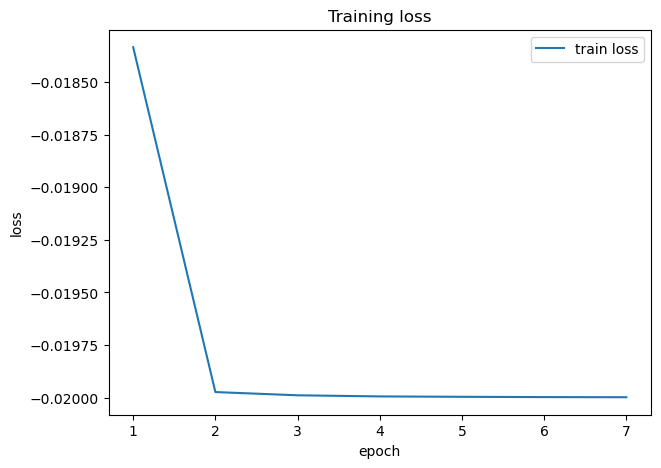

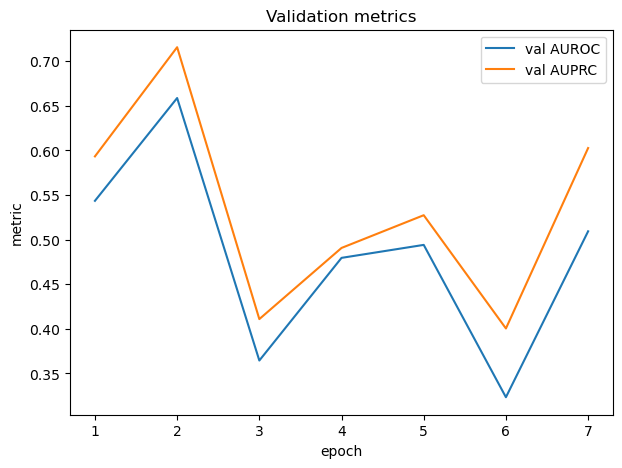

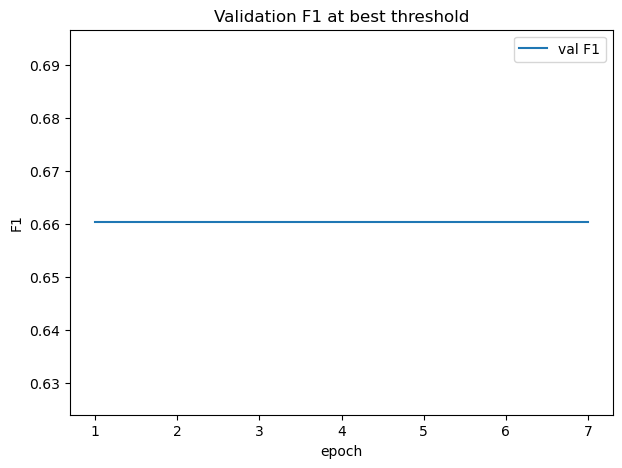

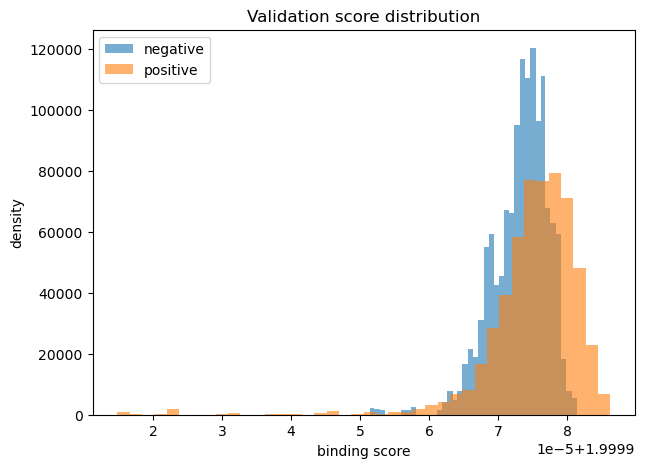

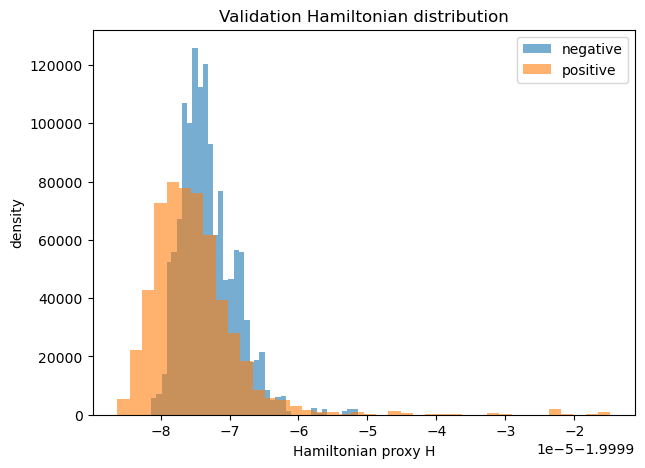

Best validation threshold: 1.9999147653579712
Validation metrics: {'auroc': 0.6586887860082304, 'auprc': 0.7156343916446591, 'threshold': 1.9999147653579712, 'f1': 0.6603260869565217, 'accuracy': 0.49290060851926976, 'precision': 0.49290060851926976, 'recall': 1.0}


In [113]:
best_val = best_result["best_state"]["val_outputs"]
best_threshold = best_result["best_state"]["threshold"]

plot_training_history(best_result["history"])
plot_score_histogram(best_val["scores"], best_val["labels"], title="Validation score distribution")
plot_H_histogram(best_val["H"], best_val["labels"], title="Validation Hamiltonian distribution")

print("Best validation threshold:", best_threshold)
print("Validation metrics:", best_result["best_state"]["val_metrics"])

g) Evaluate on test using best validation threshold

In [114]:
# use evaluation selected threshold on test

@torch.no_grad()
def evaluate_test_with_fixed_threshold(loader, tcr_projection, pmhc_projection, threshold, device, eps=1e-8):
    out = evaluate_baseline_loader(
        loader=loader,
        tcr_projection=tcr_projection,
        pmhc_projection=pmhc_projection,
        device=device,
        eps=eps,
    )

    scores = out["scores"]
    labels = out["labels"]
    preds = (scores >= threshold).astype(int)

    test_metrics = {
        "auroc": roc_auc_score(labels, scores),
        "auprc": average_precision_score(labels, scores),
        "f1": f1_score(labels, preds, zero_division=0),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds),
    }

    out["test_metrics"] = test_metrics
    out["preds"] = preds
    return out

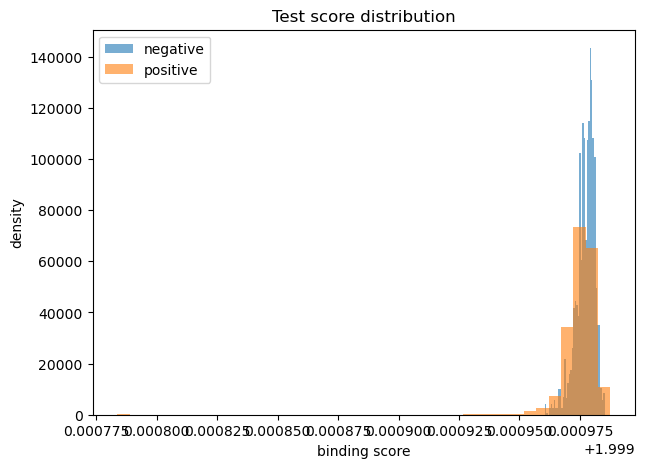

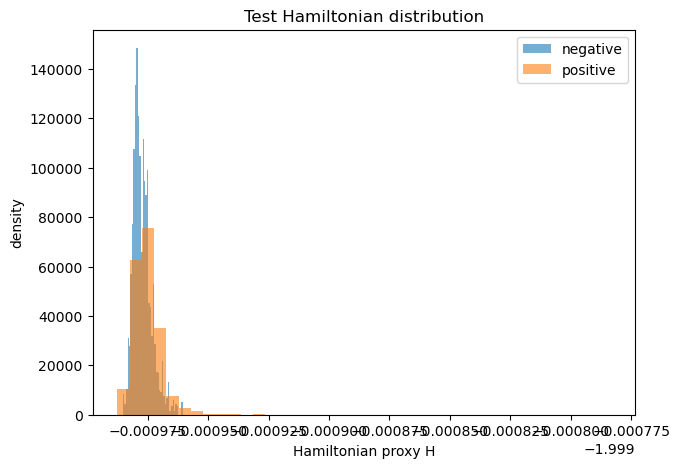

Test metrics: {'auroc': 0.3894940421631531, 'auprc': 0.4805715399316991, 'f1': 0.6855256954266855, 'accuracy': 0.5215208034433285, 'precision': 0.5216455393446544, 'recall': 0.9995417048579285, 'confusion_matrix': array([[   0, 2000],
       [   1, 2181]])}
Test confusion matrix:
 [[   0 2000]
 [   1 2181]]


In [115]:
test_out = evaluate_test_with_fixed_threshold(
    loader=test_loader,
    tcr_projection=best_result["tcr_projection"],
    pmhc_projection=best_result["pmhc_projection"],
    threshold=best_threshold,
    device=device,
)

plot_score_histogram(test_out["scores"], test_out["labels"], title="Test score distribution")
plot_H_histogram(test_out["H"], test_out["labels"], title="Test Hamiltonian distribution")

print("Test metrics:", test_out["test_metrics"])
print("Test confusion matrix:\n", test_out["test_metrics"]["confusion_matrix"])

Old Code

Training Loop

In [55]:
torch.cuda.empty_cache()
print("Cleared CUDA cache.")


Cleared CUDA cache.


In [57]:
USE_LIMIT_ZSTAR = True # flip to False when running with real Boltz

def iter_batches(train_loader, boltz_loader=None, use_limit=False):
    if use_limit:
        for batch in train_loader:
            yield batch, None
    else:
        assert boltz_loader is not None, "Need boltz_loader when use_limit=False"
        for batch, boltz_batch in zip(train_loader, boltz_loader):
            yield batch, boltz_batch

In [ ]:
#### ------------------ TRAINING WITH LIMIT CASE FOR BASELINE COMPARISON ------------------


# ---- Hyperparams ----
B, L_T_pad, D = emb_T.shape
rL = 8
rD = 16
d  = 128

eps = 1e-8  # you use eps in normalisation; define it explicitly


R_PH = 0.7
gP = torch.tensor(R_PH ** 0.5, device=device)        # scalar gate
gH = torch.tensor((1.0 - R_PH) ** 0.5, device=device)

alpha = 1.0 # The variance was dominating the loss, so this needs to scale appropriately
beta  = 1.0
delta = 1.0
gamma_var = 1.0


# ---- Global max lengths ----
sample = train_dataset[0]  # dict: emb_T/emb_P/emb_H + masks (already a batch)
L_T_max = sample["emb_T"].shape[1]
L_P_max = sample["emb_P"].shape[1]
L_H_max = sample["emb_H"].shape[1]
D       = sample["emb_T"].shape[2]

# ---- Models ----
tcr_projection  = ESMProjectionHead(D, rL, rD, d, L_max=L_T_max).to(device)
pmhc_projection = PMHCProjectionHead(
    D, rL, rD, d,
    L_P_max=L_P_max,
    L_H_max=L_H_max,
    R_PH=R_PH
).to(device)

boltz_projection = BoltzProjectionHead(
    dB=128,
    rB=16,
    rT=8,
    rPH=8,
    d=d,
    L_max=L_T_max_boltz,
    L_PH_max=L_PH_max_boltz,
).to(device)


# config 

model_type = "baseline"  # or "full"

model_name = "baseline_without_boltz" if model_type == "baseline" else "full_with_boltz"

config = dict(
    model_type=model_type,
    rL=rL, rD=rD, d=d,
    R_PH=R_PH,
    alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var,
    eps=eps,
    L_T_max=L_T_max, L_P_max=L_P_max, L_H_max=L_H_max,
    z_normalised=True,                 # because we do e_hat = z / ||z||
    hamiltonian_version="unnormalised" # very important to keep unnormalised (eventually will be encoder output)
)

print("=== Boltz Projection capacity check ===")
print("A_T rows (model TCR capacity):", boltz_projection.A_T.shape[0])
print("A_PH rows (model pMHC capacity):", boltz_projection.A_PH.shape[0])

print("Expected max L_T from manifest:", L_T_max_boltz)
print("Expected max L_PH from manifest:", L_PH_max_boltz)

# optimizer = torch.optim.Adam([
#     {"params": tcr_projection.parameters(),   "lr": 1e-3},
#     {"params": pmhc_projection.parameters(),  "lr": 1e-3},
#     {"params": boltz_projection.parameters(), "lr": 1e-5},
# ])

param_groups = [
    {"params": tcr_projection.parameters(),  "lr": 1e-3},
    {"params": pmhc_projection.parameters(), "lr": 1e-3},
]
if not USE_LIMIT_ZSTAR:
    param_groups.append({"params": boltz_projection.parameters(), "lr": 1e-5})

optimizer = torch.optim.Adam(param_groups)


for step, (batch, boltz_batch) in enumerate(iter_batches(train_loader, boltz_loader, use_limit=USE_LIMIT_ZSTAR)):

    # -----------------------
    # 1) SEQUENCE SIDE
    # -----------------------
    emb_T  = batch["emb_T"].to(device)
    mask_T = batch["mask_T"].to(device)
    emb_P  = batch["emb_P"].to(device)
    mask_P = batch["mask_P"].to(device)
    emb_H  = batch["emb_H"].to(device)
    mask_H = batch["mask_H"].to(device)

    zT  = tcr_projection(emb_T, mask_T)
    zT  = zT / (zT.norm(dim=-1, keepdim=True) + eps)

    zPH = pmhc_projection(emb_P, mask_P, emb_H, mask_H)
    zPH = zPH / (zPH.norm(dim=-1, keepdim=True) + eps)

    e_hat = torch.cat([zT, zPH], dim=-1)

    # -----------------------
    # 2) BOLTZ SIDE (optional)
    # -----------------------
    if USE_LIMIT_ZSTAR:
        z_boltz = None
        L_p = L_alpha = L_beta = L_h = None
    else:
        z_boltz = boltz_batch["z"].to(device)
        L_p     = boltz_batch["pep_len"].to(device)
        L_alpha = boltz_batch["tcra_len"].to(device)
        L_beta  = boltz_batch["tcrb_len"].to(device)
        L_h     = boltz_batch["hla_len"].to(device)

    # -----------------------
    # 3) Base loss
    # -----------------------
    loss_base, components, Zstar = non_contrastive_hamiltonian_loss(
        zT=zT, zPH=zPH, e_hat=e_hat,
        z_boltz_batch=z_boltz,
        L_alpha=L_alpha, L_beta=L_beta, L_p=L_p, L_h=L_h,
        gP=gP, gH=gH,
        boltz_projection=boltz_projection,
        alpha=alpha, beta=beta, delta=delta, gamma_var=gamma_var,
        eps=1e-4,
        return_Zstar=True,
        use_limit_Zstar=USE_LIMIT_ZSTAR,
    )

    optimizer.zero_grad(set_to_none=True)
    loss_base.backward()
    optimizer.step()

    if step % 500 == 0:
        print(step, components)
        path = save_checkpoint(
        save_dir=checkpoints_dir / model_name,
        model_name=model_name,
        step=step,
        tcr_projection=tcr_projection,
        pmhc_projection=pmhc_projection,
        boltz_projection=None if model_type == "baseline" else boltz_projection,
        optimizer=optimizer,
        config=config,
        )
        print("Saved:", path)


=== Boltz factoriser capacity check ===
A_T rows (model TCR capacity): 456
A_PH rows (model pMHC capacity): 377
Expected max L_T from manifest: 456
Expected max L_PH from manifest: 377
0 {'L_total_base': 1.0658965110778809, 'L_inv': -0.9119224548339844, 'L_var_T': 0.9890292286872864, 'L_var_PH': 0.9887896776199341, 'L_cov_T': 4.2233078145770264e-10, 'L_cov_PH': 1.0941616501725093e-09, 'quad_mean': 1.8238449096679688, 'quad_min': 1.8115119934082031, 'quad_max': 1.857572317123413, 'alpha_L_inv': -0.9119224548339844, 'beta_var': 1.9778189659118652, 'delta_cov': 1.5164924871413632e-09, 'H_expected_mean': -0.9119223952293396, 'H_actual_mean': -0.9119224548339844, 'H_max_abs_diff': 5.960464477539063e-08, 'cos_mean': -0.08807757496833801, 'H_min': -0.9287861585617065, 'H_max': -0.9057559967041016}
Saved: /home/natasha/multimodal_model/models/checkpoints/baseline_without_boltz/baseline_without_boltz/checkpoint_step_000000.pt
500 {'L_total_base': -0.019870877265930176, 'L_inv': -1.9997276067733

In [ ]:
# save model:
# a) tcr_projection
# b) pmhc_projection
# c) boltz_projection (later)
# d) optimizer state
# e) hyperparams
# f) training loop state (step, loss, components)

# make a config file
# config = {
#   "model_type": "baseline",
#   "hamiltonian": "unnormalised",
#   "z_normalised": True,
#   "alpha": alpha,
#   "beta": beta,
#   "delta": delta,
#   ...
# }

In [ ]:
# # old code
# # load ESM embeddings 

# chunk_size = 100   # set to 1000 if you want
# chunk = []
# shard_id = 0

# tcr_encoder.model.eval()
# peptide_encoder.model.eval()
# hla_encoder.model.eval()

# with torch.inference_mode():
#     for i, (tcr_batch, pep_batch, hla_batch) in enumerate(zip(train_tcr_loader, train_pep_loader, train_hla_loader)):

#         tcr_ids = tcr_batch["clean_input_ids"].to(device, non_blocking=True)
#         pep_ids = pep_batch["clean_input_ids"].to(device, non_blocking=True)
#         hla_ids = hla_batch["clean_input_ids"].to(device, non_blocking=True)

#         tcr_mask = tcr_batch["attention_mask"].to(torch.bool).cpu()
#         pep_mask = pep_batch["attention_mask"].to(torch.bool).cpu()
#         hla_mask = hla_batch["attention_mask"].to(torch.bool).cpu()

#         emb_T = tcr_encoder.model(sequence_tokens=tcr_ids).embeddings.to(torch.float16).cpu()
#         emb_P = peptide_encoder.model(sequence_tokens=pep_ids).embeddings.to(torch.float16).cpu()
#         emb_H = hla_encoder.model(sequence_tokens=hla_ids).embeddings.to(torch.float16).cpu()

#         chunk.append({
#             "emb_T": emb_T, "emb_P": emb_P, "emb_H": emb_H,
#             "mask_T": tcr_mask, "mask_P": pep_mask, "mask_H": hla_mask,
#             # optional provenance
#             "batch_idx": i,
#         })

#         # free GPU inputs ASAP
#         del tcr_ids, pep_ids, hla_ids
#         if torch.cuda.is_available() and (i % 50 == 0):
#             torch.cuda.empty_cache()

#         # write shard every chunk_size batches
#         if len(chunk) >= chunk_size:
#             torch.save(chunk, embeddings_dir / f"shard_{shard_id:05d}.pt")
#             shard_id += 1
#             chunk.clear()
#             gc.collect()

# # write last partial shard
# if chunk:
#     torch.save(chunk, embeddings_dir / f"shard_{shard_id:05d}.pt")
#     chunk.clear()
#     gc.collect()

# tcr_encoder.to("cpu")
# peptide_encoder.to("cpu")
# hla_encoder.to("cpu")
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
